In [178]:
import sys
from pathlib import Path

sys.path.insert(0, str(Path.cwd().parent.parent))

import mesmer
import model
import model_analysis

import importlib
import matplotlib.pyplot as plt
import xarray as xr

import numpy as np
from scipy.stats import skewnorm

import cartopy.crs as ccrs



In [179]:
is_local_data = False
Month_idx = 4
safe = False
start = "1950-01-01"
end = None
max_depth = 3

### Load parameters of the transformations

In [180]:
max_keys = ["emp","emp_plus1","emp_plus5","emp_plus10","Teo_min","Teo_min_plus5","mon_plus5","mon_plus10","trash"] #choice of 9 

In [181]:
parameter_sets = {}
for key in max_keys:
    parameter_sets[f"{key}_max"] = model.loading.load_params(var = "mrsol",scen= "historical", folder = f"MPI-ESM1-2-LR/variations/Maximas/{key}/local{is_local_data}/month{Month_idx}", name=f"start={start},end={end}.max_depth{max_depth}")

the mask should only change if one is based on relative data, and one is abs because the threshold has a diffrent effect

In [182]:
for key in max_keys:
    print(parameter_sets["emp_plus10_max"]["detail_mask"].equals(parameter_sets[f"{key}_max"]["detail_mask"]))


True
True
True
True
True
True
True
True
True


In [183]:
for key in max_keys:
    print(parameter_sets["emp_plus10_max"]["chunk_mask"].equals(parameter_sets[f"{key}_max"]["chunk_mask"]))


True
True
True
True
True
True
True
True
True


In [184]:
chunk_mask = parameter_sets["emp_plus10_max"]["chunk_mask"]
detal_mask = parameter_sets["emp_plus10_max"]["detail_mask"]


### Load test input and target

In [185]:
run_idx = 4
raw_mrsol_for_test = model.loading.load_data_set(var = "mrsol", local = is_local_data, run_idx=run_idx)

tas_ds = model.loading.load_data_set(var = "tas", local = is_local_data, run_idx=run_idx)
pr_ds = model.loading.load_data_set(var = "pr", local = is_local_data, run_idx=run_idx)
tas_ds = model.shape_data.prune_group_ds_timespan(tas_ds,Month_idx=Month_idx)
pr_ds = model.shape_data.prune_group_ds_timespan(pr_ds,Month_idx=Month_idx)

raw_input_for_test = xr.merge([tas_ds,pr_ds]).drop_vars("file_qf")


### shape inputs

In [186]:
def shape_input(ds, chunk_mask):
    ds = ds.sel(time=slice(start, end)).resample(time="ME").mean()
    ds = ds.sel(time= ds.time.dt.month == Month_idx)
    ds = model.mask.mask_mask(ds,chunk_mask)
    ds = mesmer.grid.stack_lat_lon(ds)
    return ds


In [187]:
input = shape_input(raw_input_for_test, chunk_mask.mrsol)

### shape targets

In [188]:
def shape_target(ds):
    #ds = ds.clip(min = 1e-32)
    ds = ds.sel(time=slice(start, end)).resample(time="ME").mean()
    ds = ds.sel(time= ds.time.dt.month == Month_idx).isel(depth=slice(0, max_depth)).drop_vars("depth_bnds")
    return ds

In [189]:
def mask_stack_target(ds):
    masked_ds, chunk_mask, detail_mask= model.mask.mask_nonpositiv_height_chunks(ds)
    ds = mesmer.grid.stack_lat_lon(masked_ds)
    ds = ds.transpose("gridcell","time", "depth")
    return ds

In [190]:
target_unstacked = shape_target(raw_mrsol_for_test)
target = mask_stack_target(target_unstacked)

glaub unnötig
rel transform
maximas = parameter_sets["rel_transform"]["local_maximas"]
rel_target = raw_mrsol_for_test/maximas
rel_target = shape_target(rel_target)
targets["rel"] = mask_stack_target(rel_target)

Log transform
log_target = shape_target(raw_mrsol_for_test)
log_target = mask_stack_target(log_target)
targets["log"] = model.transform.Log_Transform_ds(log_target)
Logit transform
maximas = parameter_sets["logit_transform"]["local_maximas"]
logit_target = raw_mrsol_for_test/maximas
logit_target = shape_target(logit_target)
logit_target = mask_stack_target(logit_target)
targets["logit"] = model.transform.Logit_Transform_ds(logit_target)

### Emulate

In [191]:
predictions = {}

In [192]:
for max_key in max_keys:
    for mot_key in ["mean","variance","skew"]:
        LinReg = model.stats._parallel_linear_regression.ParLinearRegression()
        LinReg = LinReg.from_params(parameter_sets[f"{max_key}_max"][mot_key])
        if mot_key == "skew":
            predictions[f"{max_key}_{mot_key}"] = LinReg.predict(input).transpose("gridcell","time", "depth").clip(min=-0.995,max=0.995)
        if mot_key == "variance":
            predictions[f"{max_key}_{mot_key}"] = LinReg.predict(input).transpose("gridcell","time", "depth").clip(min=1e-32)
        else:
            predictions[f"{max_key}_{mot_key}"] = LinReg.predict(input).transpose("gridcell","time", "depth")

maximas

In [193]:
maxima_versions = {}

In [194]:
for key in max_keys :
    max = model.mask.mask_mask(parameter_sets[f"{key}_max"]["local_maximas"],parameter_sets[f"{key}_max"]["chunk_mask"].mrsol).isel(depth=slice(0, max_depth))
    maxima_versions[f"{key}_max"] = mesmer.grid.stack_lat_lon(max).drop_vars("depth_bnds").transpose("gridcell","depth").mrsol


#### Scores

In [195]:
score_sets = {}


In [196]:
score_keys = max_keys

In [197]:
for key in max_keys:
    score_sets[key] = model_analysis.crps_score.crps_norm_score(predictions[f"{key}_mean"],predictions[f"{key}_variance"], target, transformation = "Logit", maximas_da = maxima_versions[f"{key}_max"],ensemble_size = 15)

In [198]:
for s_keys, scores in score_sets.items():
    score_sets[s_keys] = mesmer.grid.unstack_lat_lon_and_align(scores, target_unstacked)
    
    score_sets[s_keys] = model.mask.mask_mask(score_sets[s_keys],detal_mask.mrsol,"lon", "lat", "depth")
    

In [199]:
all_scores_ds =xr.Dataset({key : score.crps_score for key, score in score_sets.items()})

In [200]:
all_scores_ds.mean(dim=["lon","lat","time"])

<xarray.Dataset> Size: 240B
Dimensions:        (depth: 3)
Coordinates:
  * depth          (depth) float64 24B 0.03 0.19 0.78
Data variables:
    emp            (depth) float64 24B 0.4572 1.798 7.428
    emp_plus1      (depth) float64 24B 0.4248 1.68 6.903
    emp_plus5      (depth) float64 24B 0.4234 1.666 6.842
    emp_plus10     (depth) float64 24B 0.4249 1.665 6.834
    Teo_min        (depth) float64 24B 0.4476 1.722 7.08
    Teo_min_plus5  (depth) float64 24B 0.4269 1.666 6.827
    mon_plus5      (depth) float64 24B 0.4265 1.684 6.934
    mon_plus10     (depth) float64 24B 0.4232 1.672 6.861
    trash          (depth) float64 24B 0.4596 1.699 6.924

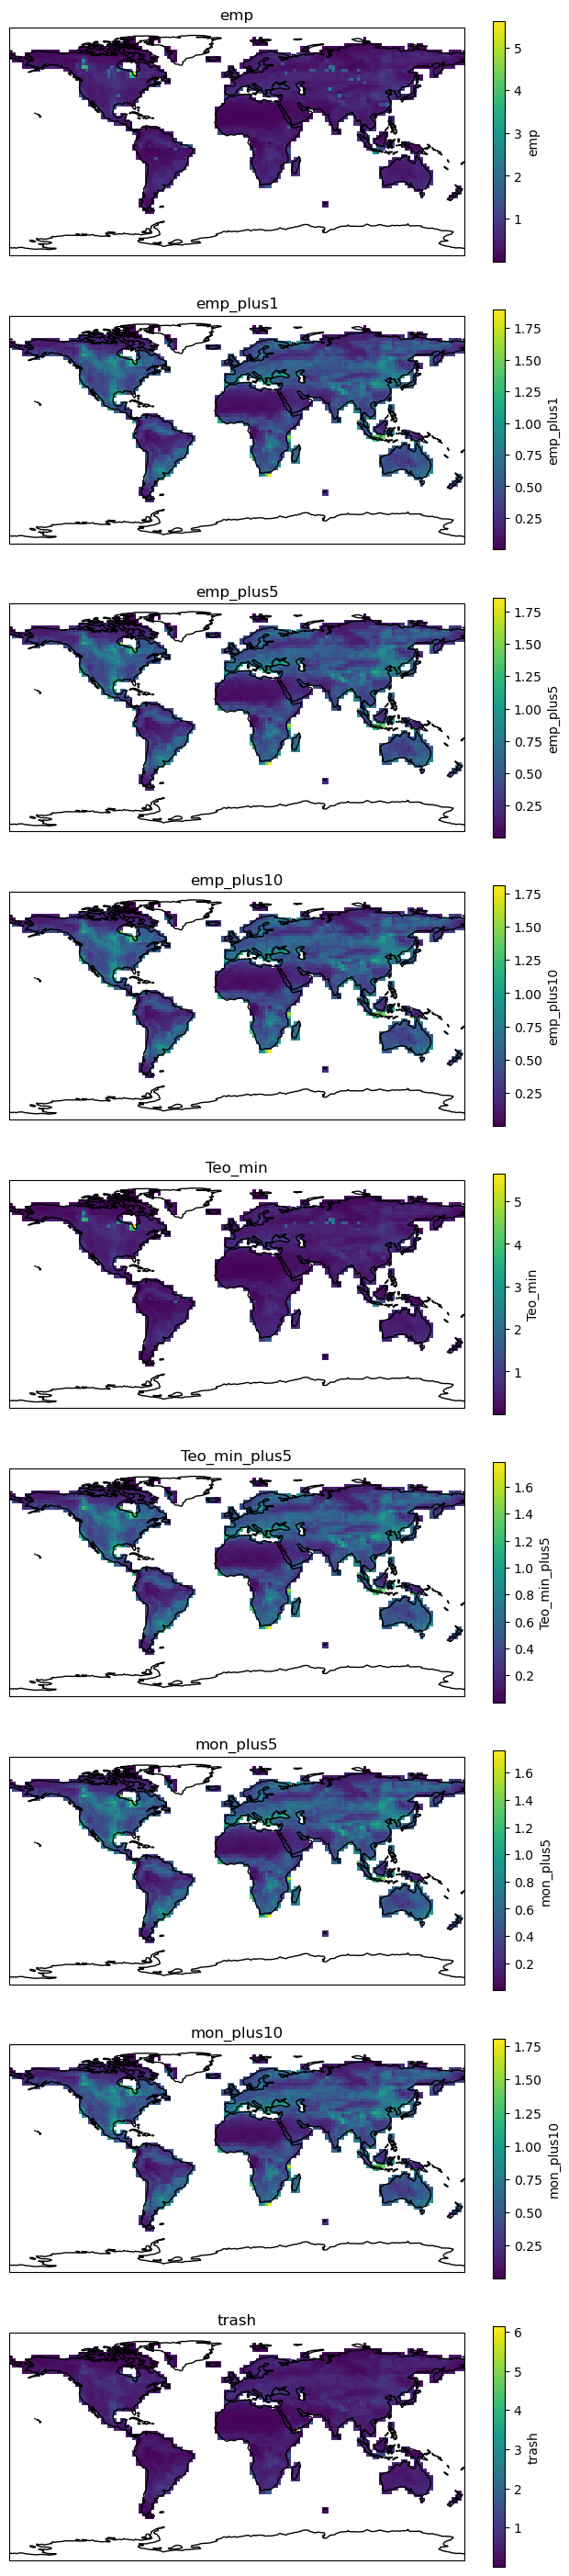

In [201]:
fig_global_crpss, ax = plt.subplots(
    subplot_kw={"projection": ccrs.PlateCarree()},
    nrows=9,
    ncols=1,
    figsize=(8, 36)
)
depth = 0

for i, s_key in enumerate(score_keys):
    da = all_scores_ds.isel(depth=depth).mean("time")[s_key]
    da.plot(ax=ax[i])
    ax[i].coastlines()
    ax[i].set_title(s_key)



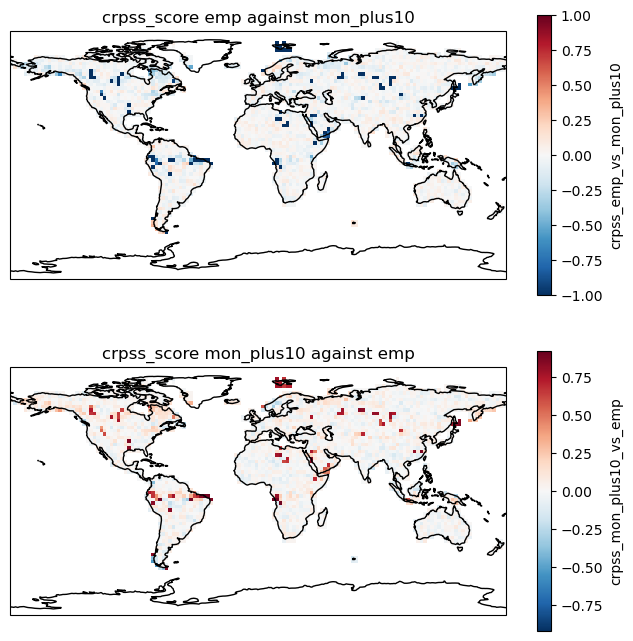

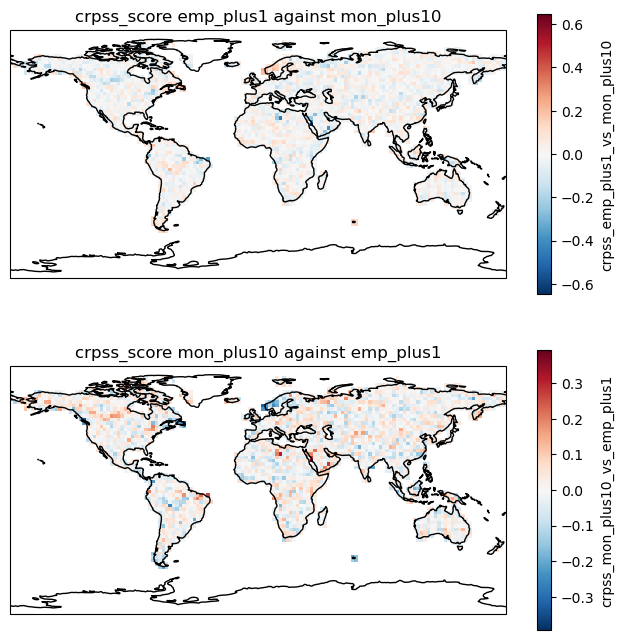

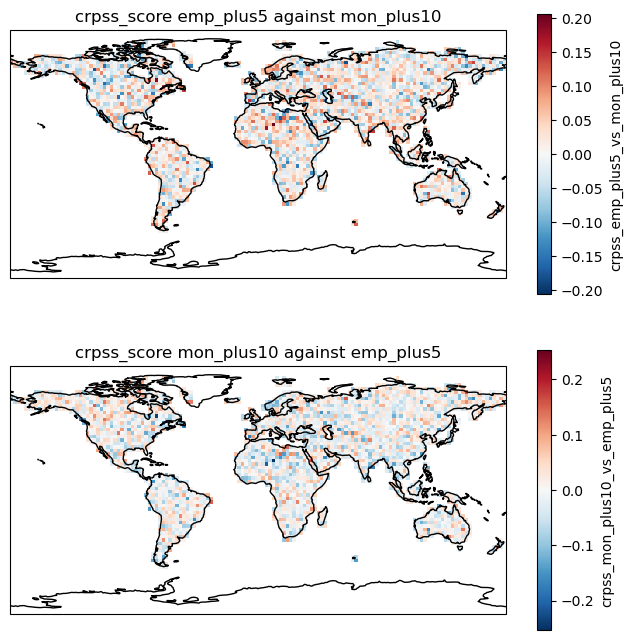

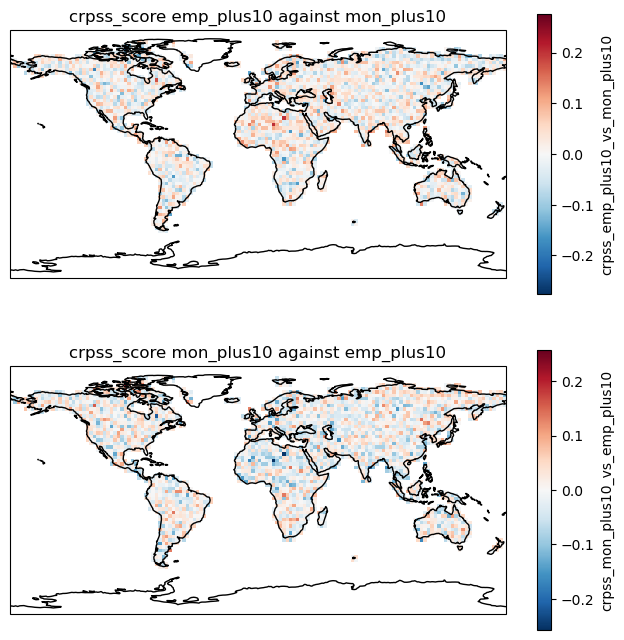

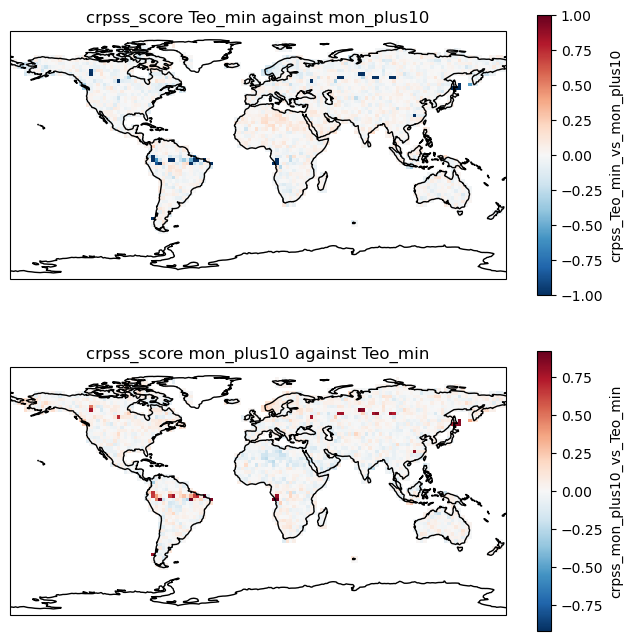

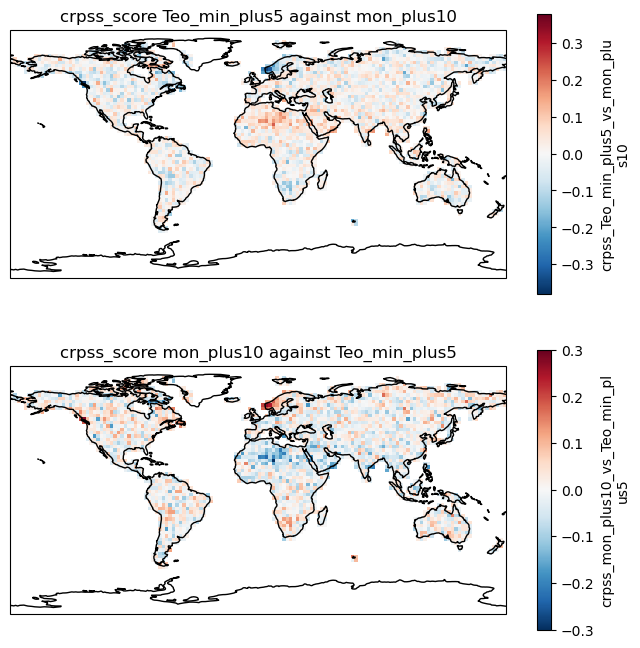

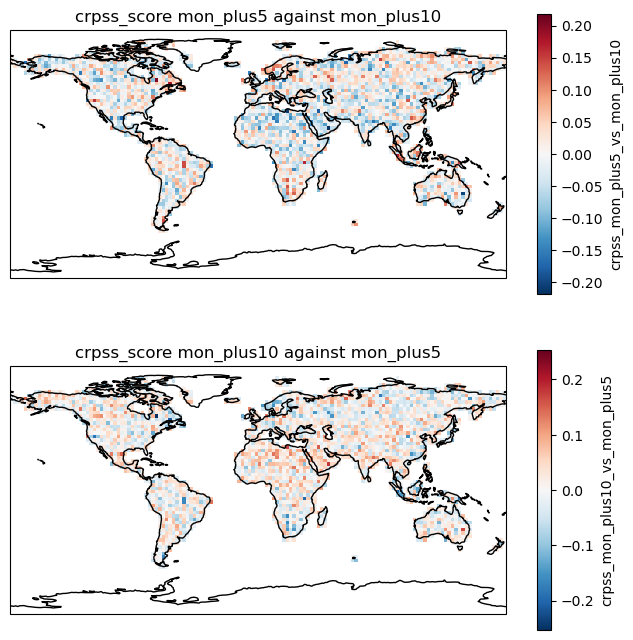

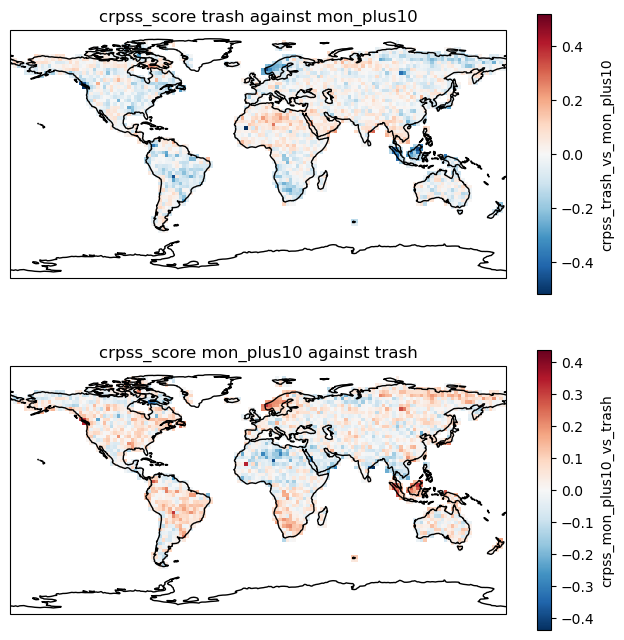

In [206]:
depth = 1

choice = "mon_plus10"

for i, s_key in enumerate(score_keys):
    if s_key == choice:
        continue
    vs = model_analysis.crps_score.combine_two_crps_and_the_crpss(score_sets[choice].crps_score,score_sets[s_key].crps_score,choice,s_key)

    fig_global_crpss, ax = plt.subplots(
    subplot_kw={"projection": ccrs.PlateCarree()},
    nrows=2,
    ncols=1,
    figsize=(8, 8)
    )
    """
    da = vs.isel(depth=depth).mean("time")[s_key]
    da.plot(ax=ax[0])
    ax[0].coastlines()
    ax[0].set_title(s_key)

    da = vs.isel(depth=depth).mean("time")[choice]
    da.plot(ax=ax[1])
    ax[1].coastlines()
    ax[1].set_title(choice)
    """
    da = vs.isel(depth=depth)[f"crpss_{s_key}_vs_{choice}"].clip(min=-1)
    da.plot(ax=ax[0])
    ax[0].coastlines()
    ax[0].set_title(f"crpss_score {s_key} against {choice}")

    da = vs.isel(depth=depth)[f"crpss_{choice}_vs_{s_key}"].clip(min=-1)
    da.plot(ax=ax[1])
    ax[1].coastlines()
    ax[1].set_title(f"crpss_score {choice} against {s_key}")

    fig_global_crpss.show()
    
